In [3]:
import xarray as xr
import numpy as np
from minisom import MiniSom
import pandas as pd
from sklearn.preprocessing import RobustScaler
import pprint
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec 
import matplotlib.colors as mcolors
from matplotlib import colormaps as cm
import matplotlib.gridspec as gridspec 
import warnings
from herbie import paint
from matplotlib.colors import ListedColormap, BoundaryNorm
import pickle

# Ignore all warnings
warnings.filterwarnings("ignore")

from som_utils import read_and_transform, build_scaler, train_som

In [4]:
ds_hail = xr.open_dataset('/scratch/userdata/bweart/pph/pper_hail_1979_2023.nc')

In [10]:
prefs = {'filename': "/scratch/userdata/bweart/pph/z500_pwat_cape.nc", 
         'vars': ['gh','pwat','cape'], 'wlon': 220, 'elon': 305, 'nlat': 55, 'slat': 20, 
         'som_config': {'x': 5, 'y': 6,'sigma': 1.5, 'random_seed': 42},
         'som_train': {'num_iteration': 10_000, 'random_order': True, 'verbose': True}}

# trained_som, trained_scaler, train_info, xr_data, npy = train_som(prefs)


In [14]:
data = {
    "trained_som": trained_som,
    "trained_scaler": trained_scaler,
    "train_info": train_info,
    "xr_data": xr_data
}

with open('som_model.pkl', 'wb') as outfile:
    pickle.dump(data, outfile)

# If you have a model pickle file, start here

In [5]:
with open("som_model.pkl", "rb") as infile:
    data = pickle.load(infile)

trained_som = data["trained_som"]
trained_scaler = data["trained_scaler"]
train_info = data["train_info"]
xr_data = data['xr_data']

In [6]:
som_data = train_info["som_train"]["data"]
win_map_idx = trained_som.win_map(som_data,return_indices=True) 

# This will create the city statistics dataframe

In [11]:
import numpy as np
import pandas as pd


def node_to_tuple(node, ny: int):
    """Accept node as tuple (i,j) or int (flat) and return (i,j)."""
    if isinstance(node, (tuple, list)) and len(node) == 2:
        return int(node[0]), int(node[1])
    k = int(node)
    return divmod(k, int(ny))


def lon_0360_to_m180_180(lon):
    """Convert 0..360 lon to -180..180."""
    lon = float(lon)
    return ((lon + 180.0) % 360.0) - 180.0


def nearest_yx_from_latlon_2d(ds_hail, target_lat, target_lon, lat_name="lat", lon_name="lon"):
    """
    Find nearest (y,x) to target lat/lon using 2D lat/lon arrays.
    Uses simple squared-distance in degrees.
    """
    lat2d = ds_hail[lat_name].values
    lon2d = ds_hail[lon_name].values

    if lat2d.ndim != 2 or lon2d.ndim != 2:
        raise ValueError("Expected 2D lat/lon arrays with dims (y,x).")

    d2 = (lat2d - float(target_lat))**2 + (lon2d - float(target_lon))**2
    flat = np.nanargmin(d2)
    iy, ix = np.unravel_index(flat, d2.shape)

    return int(iy), int(ix), float(lat2d[iy, ix]), float(lon2d[iy, ix])


def extract_node_point_stats_pper(
    *,
    xr_data,
    ds_hail,
    win_map_idx,
    ny: int,
    target_lat: float,
    target_lon: float,
    input_lon_is_0360: bool = False,   # set True if you pass 263.203
    time_shift_days: int = 1,
    pper_var: str = "p_perfect_hail",
    lat_name: str = "lat",
    lon_name: str = "lon",
    y_dim: str = "y",
    x_dim: str = "x",
    exceed_thresholds_pct=(1, 5, 10, 15, 30, 45, 60),
    data_are_fraction=None,  # None = auto-detect; True = 0..1 data; False = 0..100 data
):
    """
    Build a per-node table of point stats for PPER/PPH hail at nearest (lat,lon).

    Returns DataFrame with:
      row, col, mean_pper, p75_pper, p95_pper, max_pper, frequency

    Also adds exceedance statistics for each threshold in exceed_thresholds_pct:
      count_ge_Xpct
      frac_ge_Xpct
      pct_ge_Xpct

    Notes
    -----
    If ds_hail[pper_var] appears to be in 0..1 units, thresholds like 1,5,10,...
    are automatically converted to 0.01, 0.05, 0.10, ...
    If ds_hail[pper_var] appears to be in 0..100 units, thresholds stay as 1,5,10,...
    """

    lon_in = lon_0360_to_m180_180(target_lon) if input_lon_is_0360 else float(target_lon)
    lat_in = float(target_lat)

    # nearest grid cell
    iy, ix, lat_used, lon_used = nearest_yx_from_latlon_2d(
        ds_hail, lat_in, lon_in, lat_name=lat_name, lon_name=lon_name
    )

    # 1D time series at that grid cell
    point_series = ds_hail[pper_var].isel({y_dim: iy, x_dim: ix})  # dims: time

    # Determine whether probabilities are stored as 0..1 or 0..100
    if data_are_fraction is None:
        finite_vals = point_series.values[np.isfinite(point_series.values)]
        if finite_vals.size == 0:
            data_are_fraction = True
        else:
            data_are_fraction = float(np.nanmax(finite_vals)) <= 1.000001

    if data_are_fraction:
        exceed_thresholds_data_units = [float(t) / 100.0 for t in exceed_thresholds_pct]
    else:
        exceed_thresholds_data_units = [float(t) for t in exceed_thresholds_pct]

    nodes = list(sorted(win_map_idx.keys()))
    rows = []

    for node in nodes:
        idx_list = win_map_idx[node]
        nodesel = xr_data.isel(time=idx_list)

        # shift times by 1 day (your convention)
        time_sel = nodesel.time - np.timedelta64(time_shift_days, "D")
        time_sel = time_sel.astype("datetime64[D]").astype(str)

        # match daily times
        s_da = point_series.sel(time=time_sel, method="nearest")
        s = s_da.values
        s = s[np.isfinite(s)]

        freq = int(s.size)

        if freq == 0:
            mean = p75 = p95 = vmax = np.nan
        else:
            mean = float(np.mean(s))
            p75  = float(np.percentile(s, 75))
            p95  = float(np.percentile(s, 95))
            vmax = float(np.max(s))

        i, j = node_to_tuple(node, ny=ny)

        row_dict = {
            "row": i + 1,
            "col": j + 1,
            "mean_pper": mean,
            "p75_pper": p75,
            "p95_pper": p95,
            "max_pper": vmax,
            "frequency": freq,
        }

        # exceedance stats
        for thr_pct, thr_data in zip(exceed_thresholds_pct, exceed_thresholds_data_units):
            col_stub = f"{int(thr_pct)}pct"
            if freq == 0:
                count_exc = np.nan
                frac_exc = np.nan
                pct_exc = np.nan
            else:
                count_exc = int(np.sum(s >= thr_data))
                frac_exc = float(count_exc / freq)
                pct_exc = float(100.0 * count_exc / freq)

            row_dict[f"count_ge_{col_stub}"] = count_exc
            row_dict[f"frac_ge_{col_stub}"] = frac_exc
            row_dict[f"pct_ge_{col_stub}"] = pct_exc

        rows.append(row_dict)

    df = pd.DataFrame(rows).sort_values(["row", "col"]).reset_index(drop=True)

    # metadata for sanity checking
    df.attrs["target_lat_input"] = lat_in
    df.attrs["target_lon_input"] = float(target_lon)
    df.attrs["input_lon_is_0360"] = bool(input_lon_is_0360)
    df.attrs["nearest_lat_used"] = lat_used
    df.attrs["nearest_lon_used"] = lon_used
    df.attrs["nearest_y_index"] = iy
    df.attrs["nearest_x_index"] = ix
    df.attrs["data_are_fraction"] = bool(data_are_fraction)
    df.attrs["exceed_thresholds_pct"] = tuple(exceed_thresholds_pct)
    df.attrs["exceed_thresholds_data_units"] = tuple(exceed_thresholds_data_units)

    return df

In [12]:
df_dallas = extract_node_point_stats_pper(
    xr_data=xr_data,
    ds_hail=ds_hail,
    win_map_idx=win_map_idx,
    ny=prefs["som_config"]["y"],
    target_lat=41.2565,
    target_lon=-95.9345,
)
df_dallas

,row,col,mean_pper,p75_pper,p95_pper,max_pper,frequency,count_ge_1pct,frac_ge_1pct,pct_ge_1pct,...,pct_ge_15pct,count_ge_30pct,frac_ge_30pct,pct_ge_30pct,count_ge_45pct,frac_ge_45pct,pct_ge_45pct,count_ge_60pct,frac_ge_60pct,pct_ge_60pct
0,1,1,2.854498,2.827253,15.513692,32.245105,215,72,0.334884,33.488372,...,6.046512,3,0.013953,1.395349,0,0.000000,0.000000,0,0.000000,0.000000
1,1,2,1.274999,0.039313,8.370764,28.821663,210,30,0.142857,14.285714,...,2.857143,0,0.000000,0.000000,0,0.000000,0.000000,0,0.000000,0.000000
2,1,3,1.860398,0.027346,12.892133,37.001294,245,44,0.179592,17.959184,...,4.081633,2,0.008163,0.816327,0,0.000000,0.000000,0,0.000000,0.000000
3,1,4,0.130622,0.000000,0.002523,18.078114,285,5,0.017544,1.754386,...,0.350877,0,0.000000,0.000000,0,0.000000,0.000000,0,0.000000,0.000000
4,1,5,0.000698,0.000000,0.000000,0.239977,358,0,0.000000,0.000000,...,0.000000,0,0.000000,0.000000,0,0.000000,0.000000,0,0.000000,0.000000
5,1,6,0.024791,0.000000,0.000000,10.660227,430,1,0.002326,0.232558,...,0.000000,0,0.000000,0.000000,0,0.000000,0.000000,0,0.000000,0.000000
6,2,1,2.099096,1.022836,11.508121,32.051652,191,49,0.256545,25.654450,...,4.188482,2,0.010471,1.047120,0,0.000000,0.000000,0,0.000000,0.000000
7,2,2,0.754914,0.003787,2.806961,37.836856,228,24,0.105263,10.526316,...,1.315789,1,0.004386,0.438596,0,0.000000,0.000000,0,0.000000,0.000000
8,2,3,0.368533,0.000000,0.144102,42.045585,173,5,0.028902,2.890173,...,0.578035,1,0.005780,0.578035,0,0.000000,0.000000,0,0.000000,0.000000
9,2,4,0.207203,0.000000,0.011674,19.860254,258,8,0.031008,3.100775,...,0.387597,0,0.000000,0.000000,0,0.000000,0.000000,0,0.000000,0.000000


In [13]:
import numpy as np
import matplotlib.pyplot as plt


def row_number_to_letters(n):
    """
    Convert 1-based row number to Excel-style letters:
    1 -> A, 2 -> B, ..., 26 -> Z, 27 -> AA, ...
    """
    result = ""
    while n > 0:
        n, rem = divmod(n - 1, 26)
        result = chr(65 + rem) + result
    return result


def plot_flattened_node_exceedance(
    df,
    thresholds=(1, 5, 10, 15, 30, 45, 60),
    value_type="count",   # "count", "pct", or "frac"
    title=None,
):
    """
    Plot node ID (A1, A2, ..., B1, B2, ...) vs exceedance statistics.
    """

    df_plot = df.copy().sort_values(["row", "col"]).reset_index(drop=True)

    # make node IDs like A1, A2, ..., B1, B2, ...
    df_plot["node_id"] = [
        f"{row_number_to_letters(row)}{col}"
        for row, col in zip(df_plot["row"], df_plot["col"])
    ]

    x = np.arange(len(df_plot))

    if value_type == "count":
        prefix = "count_ge_"
        ylabel = "Frequency of exceedance"
    elif value_type == "pct":
        prefix = "pct_ge_"
        ylabel = "Percent of exceedance"
    elif value_type == "frac":
        prefix = "frac_ge_"
        ylabel = "Fraction of exceedance"
    else:
        raise ValueError("value_type must be 'count', 'pct', or 'frac'")

    threshold_colors = {
        1: "#90EE90",   # light green
        5: "#008000",   # green
        10: "#FFFF00",  # yellow
        15: "#8B4513",  # brown
        30: "#FF0000",  # red
        45: "#FFC0CB",  # pink
        60: "#800080",  # purple
    }

    fig, ax = plt.subplots(figsize=(16, 8), dpi=200)

    for thr in thresholds:
        colname = f"{prefix}{thr}pct"
        if colname not in df_plot.columns:
            print(f"Skipping missing column: {colname}")
            continue

        ax.plot(
            x,
            df_plot[colname],
            marker="o",
            linewidth=2,
            color=threshold_colors.get(thr, None),
            label=f">= {thr}%"
        )

    ax.set_xlabel("Node")
    ax.set_ylabel(ylabel)

    if title is None:
        title = f"Node vs {ylabel}"
    ax.set_title(title)

    ax.set_xticks(x)
    ax.set_xticklabels(df_plot["node_id"], rotation=0)

    for xi in x:
        ax.axvline(x=xi, linewidth=0.5, alpha=0.15)

    ax.grid(True, alpha=0.3)
    ax.legend(title="Threshold", loc="best")

    plt.tight_layout()
    plt.show()

    return df_plot

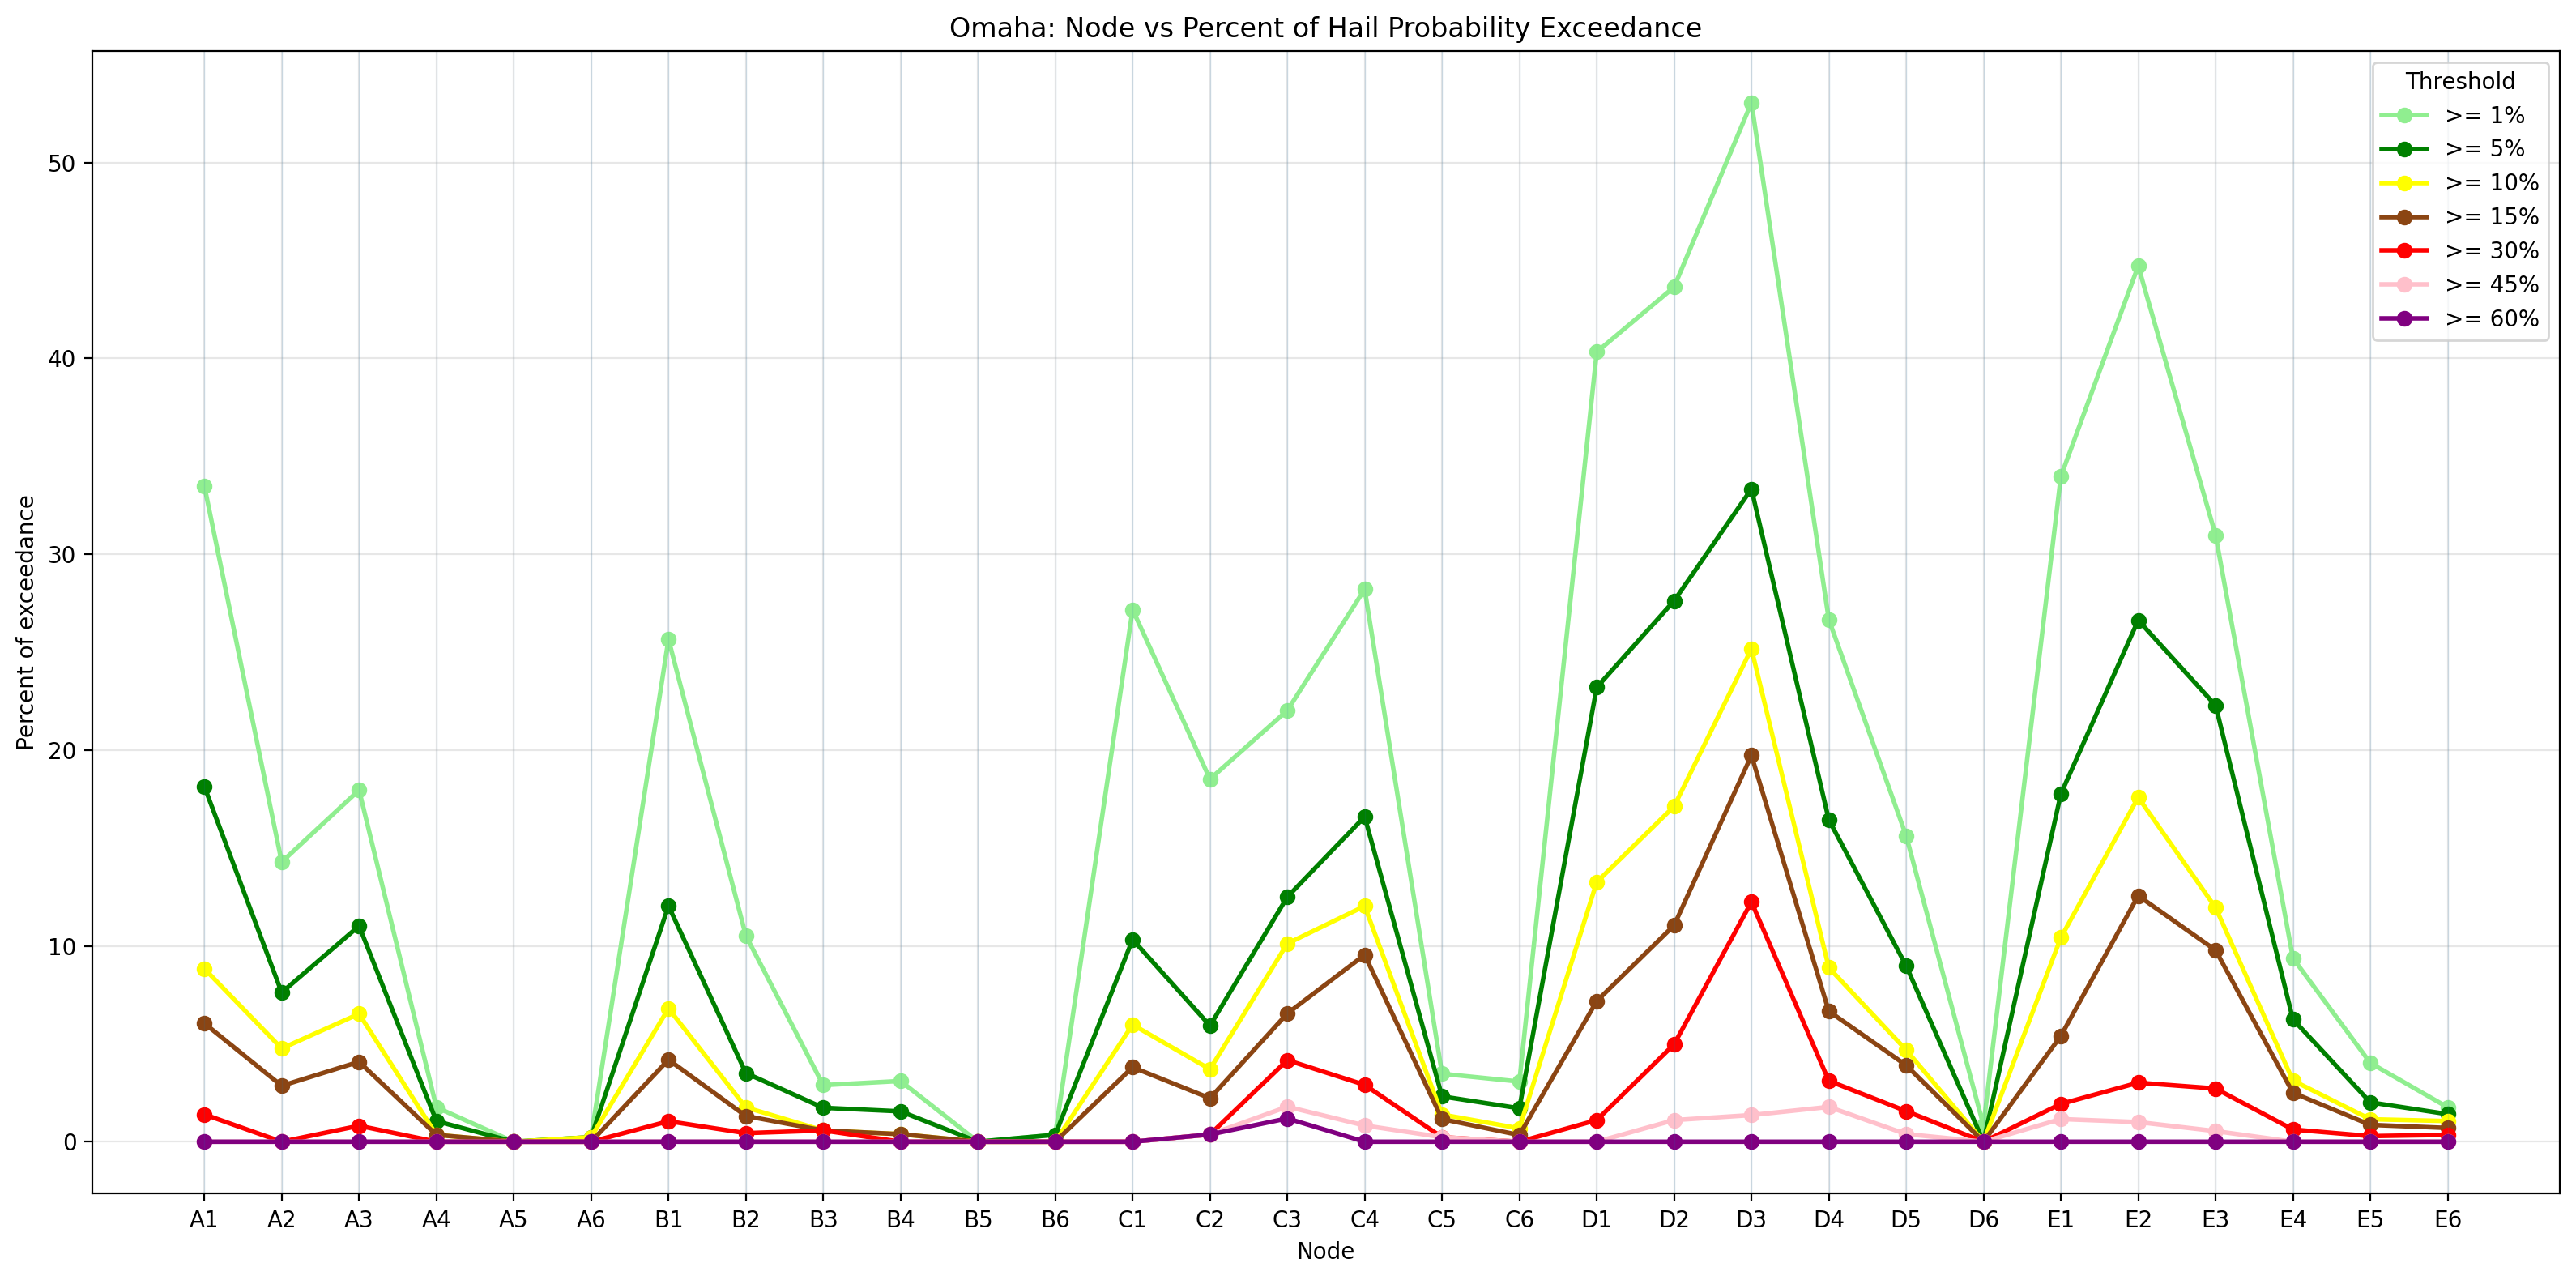

In [14]:
df_dallas_plot = plot_flattened_node_exceedance(
    df_dallas,
    thresholds=(1, 5, 10, 15, 30, 45, 60),
    value_type="pct",
    title="Omaha: Node vs Percent of Hail Probability Exceedance"
)

# Creating node occurrences per year

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def row_number_to_letters(n):
    """
    Convert 1-based row number to Excel-style letters:
    1 -> A, 2 -> B, ..., 26 -> Z, 27 -> AA, ...
    """
    result = ""
    while n > 0:
        n, rem = divmod(n - 1, 26)
        result = chr(65 + rem) + result
    return result


def extract_node_frequency_per_year(
    *,
    xr_data,
    win_map_idx,
    ny,
    time_shift_days=1,
    unique_days=True,
    normalize=False,
):
    """
    Build a dataframe of node frequency per year.

    Parameters
    ----------
    xr_data : xarray Dataset or DataArray
        Must have a time coordinate.
    win_map_idx : dict
        Mapping of SOM node -> indices in xr_data.time
    ny : int
        Number of SOM columns
    time_shift_days : int
        Shift node times backward by this many days
    unique_days : bool
        If True, count unique calendar days only within each node.
        If False, count every sample.
    normalize : bool
        If True, return percent of yearly total instead of raw counts.

    Returns
    -------
    df_long : DataFrame
        Long-form table with columns:
        year, row, col, node_number, node_id, frequency
    df_wide : DataFrame
        Wide table with years as rows and node_id as columns
    """

    rows = []

    for node in sorted(win_map_idx.keys()):
        idx_list = np.asarray(win_map_idx[node], dtype=int)

        times = pd.to_datetime(xr_data.time.isel(time=idx_list).values)
        times = times - pd.to_timedelta(time_shift_days, unit="D")

        if unique_days:
            times = pd.DatetimeIndex(times).normalize().unique()
        else:
            times = pd.DatetimeIndex(times)

        if len(times) == 0:
            continue

        years = pd.Series(times.year)
        counts = years.value_counts().sort_index()

        i, j = node_to_tuple(node, ny=ny)

        for year, freq in counts.items():
            rows.append({
                "year": int(year),
                "row": i + 1,
                "col": j + 1,
                "node_number": i * ny + j + 1,
                "node_id": f"{row_number_to_letters(i + 1)}{j + 1}",
                "frequency": int(freq),
            })

    df_long = pd.DataFrame(rows).sort_values(["year", "row", "col"]).reset_index(drop=True)

    if df_long.empty:
        return df_long, pd.DataFrame()

    if normalize:
        yearly_totals = df_long.groupby("year")["frequency"].transform("sum")
        df_long["frequency"] = 100.0 * df_long["frequency"] / yearly_totals

    df_wide = (
        df_long.pivot(index="year", columns="node_id", values="frequency")
        .sort_index(axis=1)
        .sort_index()
    )

    return df_long, df_wide

In [22]:
df_node_year_long, df_node_year_wide = extract_node_frequency_per_year(
    xr_data=xr_data,
    win_map_idx=win_map_idx,
    ny=prefs["som_config"]["y"],
    time_shift_days=1,
    unique_days=True,
    normalize=False,
)

df_node_year_long

,year,row,col,node_number,node_id,frequency
0,1999,5,5,29,E5,1
1,2000,1,1,1,A1,11
2,2000,1,2,2,A2,12
3,2000,1,3,3,A3,9
4,2000,1,4,4,A4,11
...,...,...,...,...,...,...
594,2019,5,2,26,E2,12
595,2019,5,3,27,E3,9
596,2019,5,4,28,E4,10
597,2019,5,5,29,E5,32


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import BoundaryNorm
plt.style.use('default')

def _nice_integer_step(vmax, target_bins=8):
    """
    Choose a nice integer step size like 1, 2, 5, 10, 20, ...
    """
    if vmax <= 0:
        return 1

    raw = vmax / max(target_bins, 1)
    magnitude = 10 ** np.floor(np.log10(raw))
    residual = raw / magnitude

    if residual <= 1:
        nice = 1
    elif residual <= 2:
        nice = 2
    elif residual <= 5:
        nice = 5
    else:
        nice = 10

    step = int(max(1, nice * magnitude))
    return step


def plot_node_frequency_heatmap(
    df_wide,
    title="Node Frequency per Year",
    ylabel="Year",
    xlabel="Node",
    cmap="magma",
    annotate=False,
    start_year=2000,
    end_year=2019,
    highlight_max_per_node=True,
    highlight_color="white",
    highlight_linewidth=2.5,
    target_color_bins=24,
    colorbar_step=None,   # set manually if you want, e.g. 1 or 2
):
    """
    Heatmap of node frequency by year with whole-number, sensible colorbar steps.
    """
    df_plot = df_wide.copy()

    # fill missing year-node combinations with 0
    df_plot = df_plot.fillna(0)

    # keep only requested years
    df_plot = df_plot.loc[(df_plot.index >= start_year) & (df_plot.index <= end_year)]

    data = df_plot.values.astype(float)

    # determine integer colorbar steps
    vmax = int(np.ceil(np.nanmax(data)))
    vmin = 0

    if colorbar_step is None:
        step = _nice_integer_step(vmax, target_bins=target_color_bins)
    else:
        step = int(max(1, colorbar_step))

    upper = int(np.ceil(vmax / step) * step)
    if upper == 0:
        upper = step

    boundaries = np.arange(vmin, upper + step, step)

    cmap_obj = plt.get_cmap(cmap, len(boundaries) - 1)
    norm = BoundaryNorm(boundaries, cmap_obj.N, clip=True)

    fig, ax = plt.subplots(figsize=(16, 8), dpi=200)

    im = ax.imshow(
        data,
        aspect="auto",
        origin="lower",
        cmap=cmap_obj,
        norm=norm,
    )

    ax.set_xticks(np.arange(len(df_plot.columns)))
    ax.set_xticklabels(df_plot.columns, rotation=90)

    ax.set_yticks(np.arange(len(df_plot.index)))
    ax.set_yticklabels(df_plot.index.astype(int))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    cbar = plt.colorbar(
        im,
        ax=ax,
        boundaries=boundaries,
        ticks=boundaries,
        spacing="proportional",
        pad=0.01
    )
    cbar.set_label("Frequency")
    cbar.ax.set_yticklabels([f"{int(t)}" for t in boundaries])

    if annotate:
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                val = data[i, j]
                ax.text(j, i, f"{int(round(val))}", ha="center", va="center", fontsize=6)

    # outline max year(s) for each node
    if highlight_max_per_node:
        for j in range(data.shape[1]):
            col = data[:, j]

            if not np.any(np.isfinite(col)):
                continue

            max_val = np.nanmax(col)
            max_rows = np.where(np.isfinite(col) & (col == max_val))[0]

            for i in max_rows:
                rect = Rectangle(
                    (j - 0.5, i - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor=highlight_color,
                    linewidth=highlight_linewidth,
                )
                ax.add_patch(rect)

    plt.tight_layout()
    plt.show()

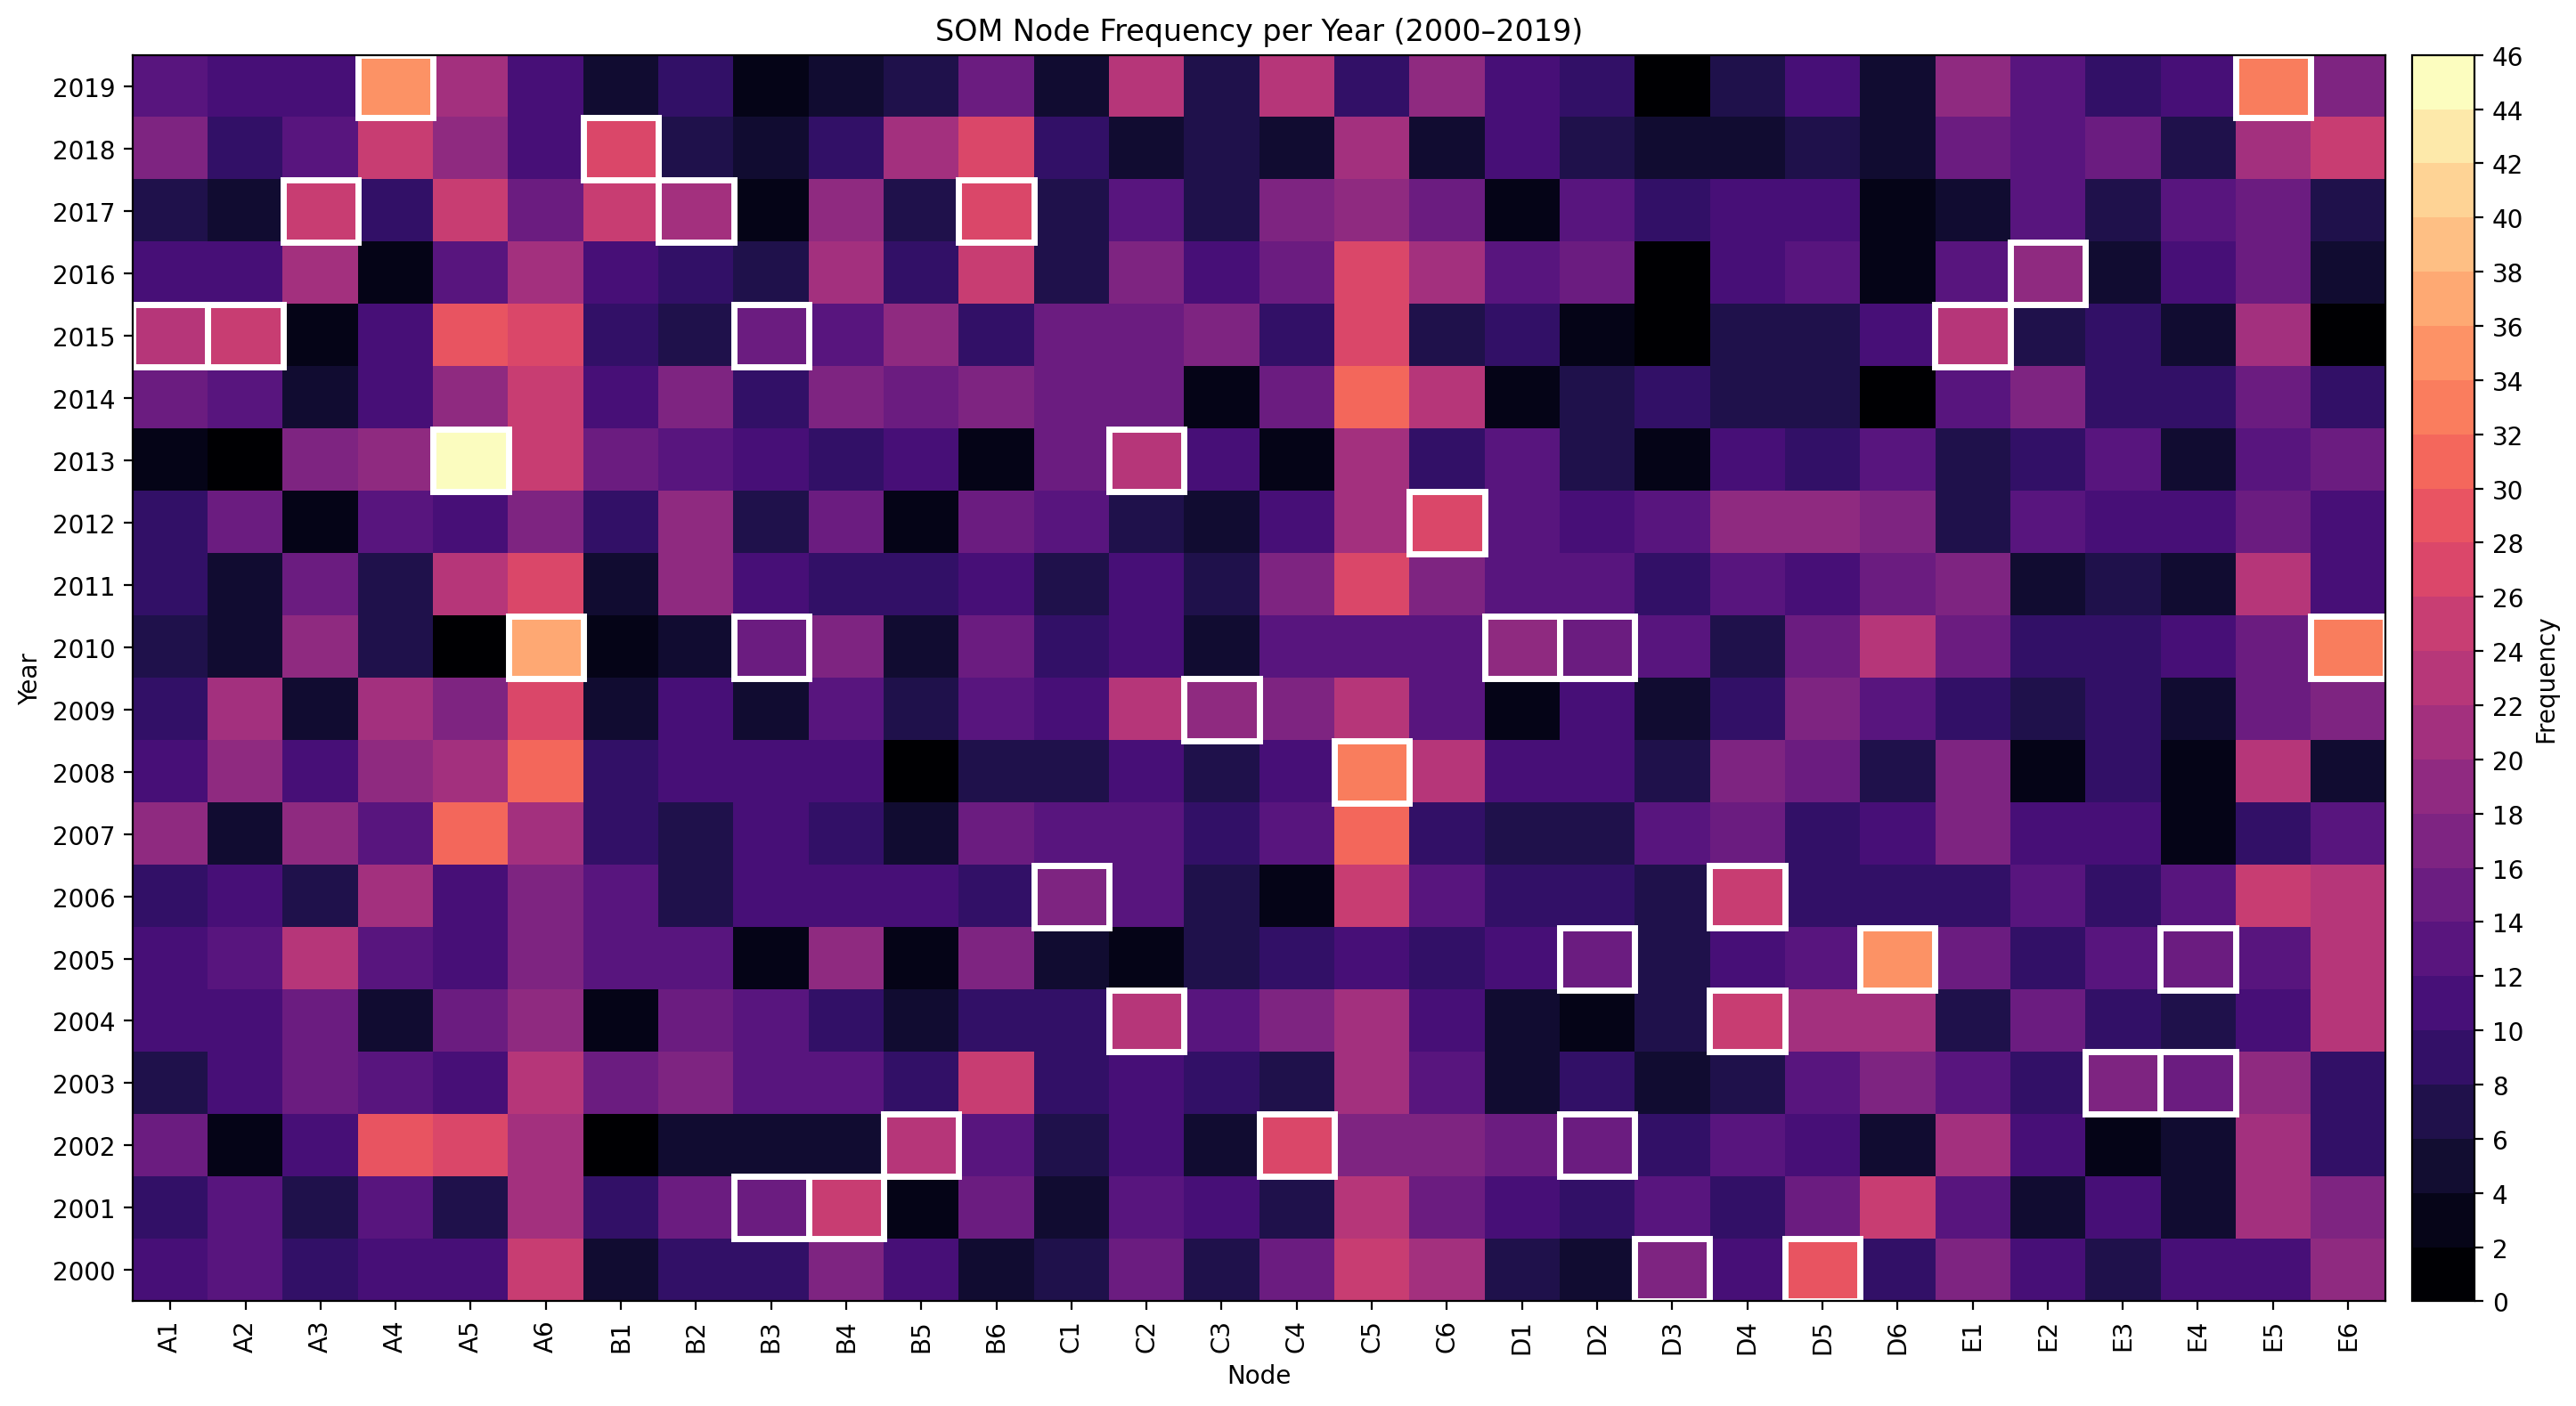

In [24]:
plot_node_frequency_heatmap(
    df_node_year_wide,
    title="SOM Node Frequency per Year (2000–2019)",
    start_year=2000,
    end_year=2019
)